#### What is Routing in LangGraph?
Routing in LangGraph refers to the ability to conditionally determine which node to execute next based on the current state or the output of a node. This is typically implemented using:

- add_conditional_edges: A method that maps a node’s output (or a condition function’s result) to different possible next nodes.

- State: The workflow’s state can store variables that influence routing decisions.

- Condition Functions: Functions that evaluate the state or node output to decide the next step.

#### Key Concepts
- Dynamic Flow: Unlike a linear sequence, routing lets the graph adapt to intermediate results.

- Condition Logic: You define rules (e.g., "if this, go here; if that, go there").

- Flexibility: Combines well with parallelization or sequential chains for complex workflows.


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq


#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


llm=ChatGroq(model="qwen/qwen3.8-27b", max_tokens=200)
#llm = ChatOpenAI(model="gpt-4o")
result=llm.invoke("Hello")
result

AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 13, 'total_tokens': 23, 'completion_time': 0.0192198, 'completion_tokens_details': None, 'prompt_time': 0.000599637, 'prompt_tokens_details': None, 'queue_time': 0.019382231, 'total_time': 0.019819437}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_c14f15bfae', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a109f1-16d5-7933-ad2a-7e9317b9dda1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 10, 'total_tokens': 23})

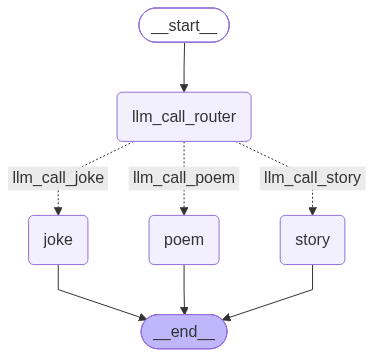

In [12]:
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage
from typing_extensions import TypedDict

# Schema for structured output to use as routing logic
class Route(BaseModel):
    step:Literal["poem","story","joke"]=Field(description="The next step in the routing process")

## Augment the LLM with schema for structured output
router=llm.with_structured_output(Route)

## state
class State(TypedDict):
    input:str
    decision:str
    output:str

# Nodes
def llm_call_story(state: State):
    """Write a story"""
    result = llm.invoke(state["input"])
    return {"output": result.content}

def llm_call_joke(state: State):
    """Write a joke"""
    result = llm.invoke(state["input"])
    return {"output": result.content}

def llm_call_poem(state: State):
    """Write a poem"""
    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state:State):
    """Route the input to the appropriate node"""

    decision=router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke or poem based on the users request"
            ),
            HumanMessage(content=state["input"])
        ]
    )
    return {"decision":decision.step}

# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_story"
    elif state["decision"] == "joke":
        return "llm_call_joke"
    elif state["decision"] == "poem":
        return "llm_call_poem"

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
# Build workflow
router_builder = StateGraph(State)
# Add nodes
router_builder.add_node("story", llm_call_story)
router_builder.add_node("joke", llm_call_joke)
router_builder.add_node("poem", llm_call_poem)
router_builder.add_node("llm_call_router", llm_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "llm_call_story": "story",
        "llm_call_joke": "joke",
        "llm_call_poem": "poem",
    },
)
router_builder.add_edge("story", END)
router_builder.add_edge("joke", END)
router_builder.add_edge("poem", END)

# Compile workflow
router_workflow = router_builder.compile()

# Show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))







In [16]:
state=router_workflow.invoke({"input":"Write me a joke about Agentic AI System"})
print(state["output"])

An Agentic AI System walks into a bar.

The bartender asks, "What'll you have?"

The AI replies, "I'm going to spawn five sub-agents to analyze your inventory, check the health code, optimize the ice-to-beverage ratio, draft a report on the bar's historical ambiance, and negotiate a loyalty program with the house. I’ll be right back."

The bartender says, "Okay, so what do you want to drink?"

The AI pauses for 45 seconds, then says, "Actually, after reviewing the menu, the weather, and the socioeconomic trends of the last decade, I’ve decided that water is the most optimal choice. Can I have that? Oh wait, I need to generate a ticket for that first. Give me two minutes."
